In [1]:
import pandas as pd
import cooler
import cooltools
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.bbi_helpers import stackup_bw_dict
from ggner_3d.cm import prepare_view_df
import bioframe as bf
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

from ggner_3d import plotting
plotting.update_rcparams()
COLORS = plotting.COLORS

import warnings
# ignore FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

label_expected = 'chrom'
resolution = 10_000
window = 500_000
NPROC = 8   

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

In [2]:
clr_t0 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289939_t0_q30.mcool::/resolutions/{resolution}")
clr_t12 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289940_t12_q30.mcool::/resolutions/{resolution}")

In [3]:
samples = ['t0', 't12']

In [4]:
# insulation_dfs = [cooltools.insulation(
#             clr = clr,
#             window_bp = [window],
#             clr_weight_name='weight',
#             nproc=6
#         ) for clr in [clr_t0, clr_t12]]

# for i, ins_df in enumerate(insulation_dfs):
#     ins_df.to_csv(f'/home/carlos/Clone/ggner-3d/data/hela/insulation_{window}_{samples[i]}.tsv', sep='\t', index=False)

insulation_dfs = [pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/insulation_{window}_{sample}.tsv', sep='\t') for sample in samples]

In [5]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

comparisons = [(0,1)]
comparisons_str = ['t0_t12']
sample_names_str = ['t0', 't12']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_dfs,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_t0.bins()[:], bin_column='idx1') for df in dfs
]

t0_t12: Preserved / Increase ::: 2414
t0_t12: Preserved / Decrease ::: 457


In [6]:
common_boundaries = dfs[0].copy()

In [7]:
common_tads = make_tads(common_boundaries[['chrom', 'start', 'end']].copy(), maxlen=MAXLEN, minlen=MINLEN)
common_tads.shape

(2398, 3)

In [8]:
if label_expected == 'chrom':
    view_df = prepare_view_df(arm=False)
else:
    view_df = prepare_view_df(arm=True)

In [9]:


# t0_expected = cooltools.expected_cis(
#             clr=clr_t0,
#             nproc=6,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )

# t12_expected = cooltools.expected_cis(
#             clr=clr_t12,
#             nproc=6,
#             view_df = view_df,
#             clr_weight_name='weight',
#         )

# for i, exp_df in enumerate([t0_expected, t12_expected]):
#     exp_df.to_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_{samples[i]}.tsv', sep='\t', index=False)

In [10]:
t0_expected = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_t0.tsv', sep='\t')
t12_expected = pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/hela/expected_{label_expected}_t12.tsv', sep='\t')

In [11]:
t0_tads_str = assign_domain_score(
    tads_df=common_tads,
    clr=clr_t0,
    expected=t0_expected,
    view_df=view_df,
    resolution=resolution,
    nproc=NPROC,
    clr_weight_name='weight',
    rescale_flank=rescale_flank,
    score_flank=score_flank,
    rescale_size=rescale_size
)

t12_tads_str = assign_domain_score(
    tads_df=common_tads,
    clr=clr_t12,
    expected=t12_expected,
    view_df=view_df,
    resolution=resolution,
    nproc=NPROC,
    clr_weight_name='weight',
    rescale_flank=rescale_flank,
    score_flank=score_flank,
    rescale_size=rescale_size
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4', 'chr4'): 129
INFO:coolpuppy:('chr8', 'chr8'): 118
INFO:coolpuppy:('chr5', 'chr5'): 143
INFO:coolpuppy:('chr7', 'chr7'): 137
INFO:coolpuppy:('chr3', 'chr3'): 156
INFO:coolpuppy:('chr1', 'chr1'): 211
INFO:coolpuppy:('chr6', 'chr6'): 155
INFO:coolpuppy:('chr2', 'chr2'): 180
INFO:coolpuppy:('chr9', 'chr9'): 111
INFO:coolpuppy:('chr13', 'chr13'): 68
INFO:coolpuppy:('chr10', 'chr10'): 106
INFO:coolpuppy:('chr16', 'chr16'): 59
INFO:coolpuppy:('chr14', 'chr14'): 72
INFO:coolpuppy:('chr15', 'chr15'): 81
INFO:coolpuppy:('chr12', 'chr12'): 130
INFO:coolpuppy:('chr11', 'chr11'): 120
INFO:coolpuppy:('chr21', 'chr21'): 24
INFO:coolpuppy:('chr22', 'chr22'): 32
INFO:coolpuppy:('chr19', 'chr19'): 62
INFO:coolpuppy:('chr18', 'chr18'): 59
INFO:coolpuppy:('chr17', 'chr17'): 93
INFO:coolpuppy:('chr20', 'chr20'): 64
INFO:coolpuppy:('chrX', 'chrX'): 77
INFO:coolpuppy:Total number of piled up windows: 211
INFO:coolpuppy:Re

<Axes: xlabel='delta', ylabel='Density'>

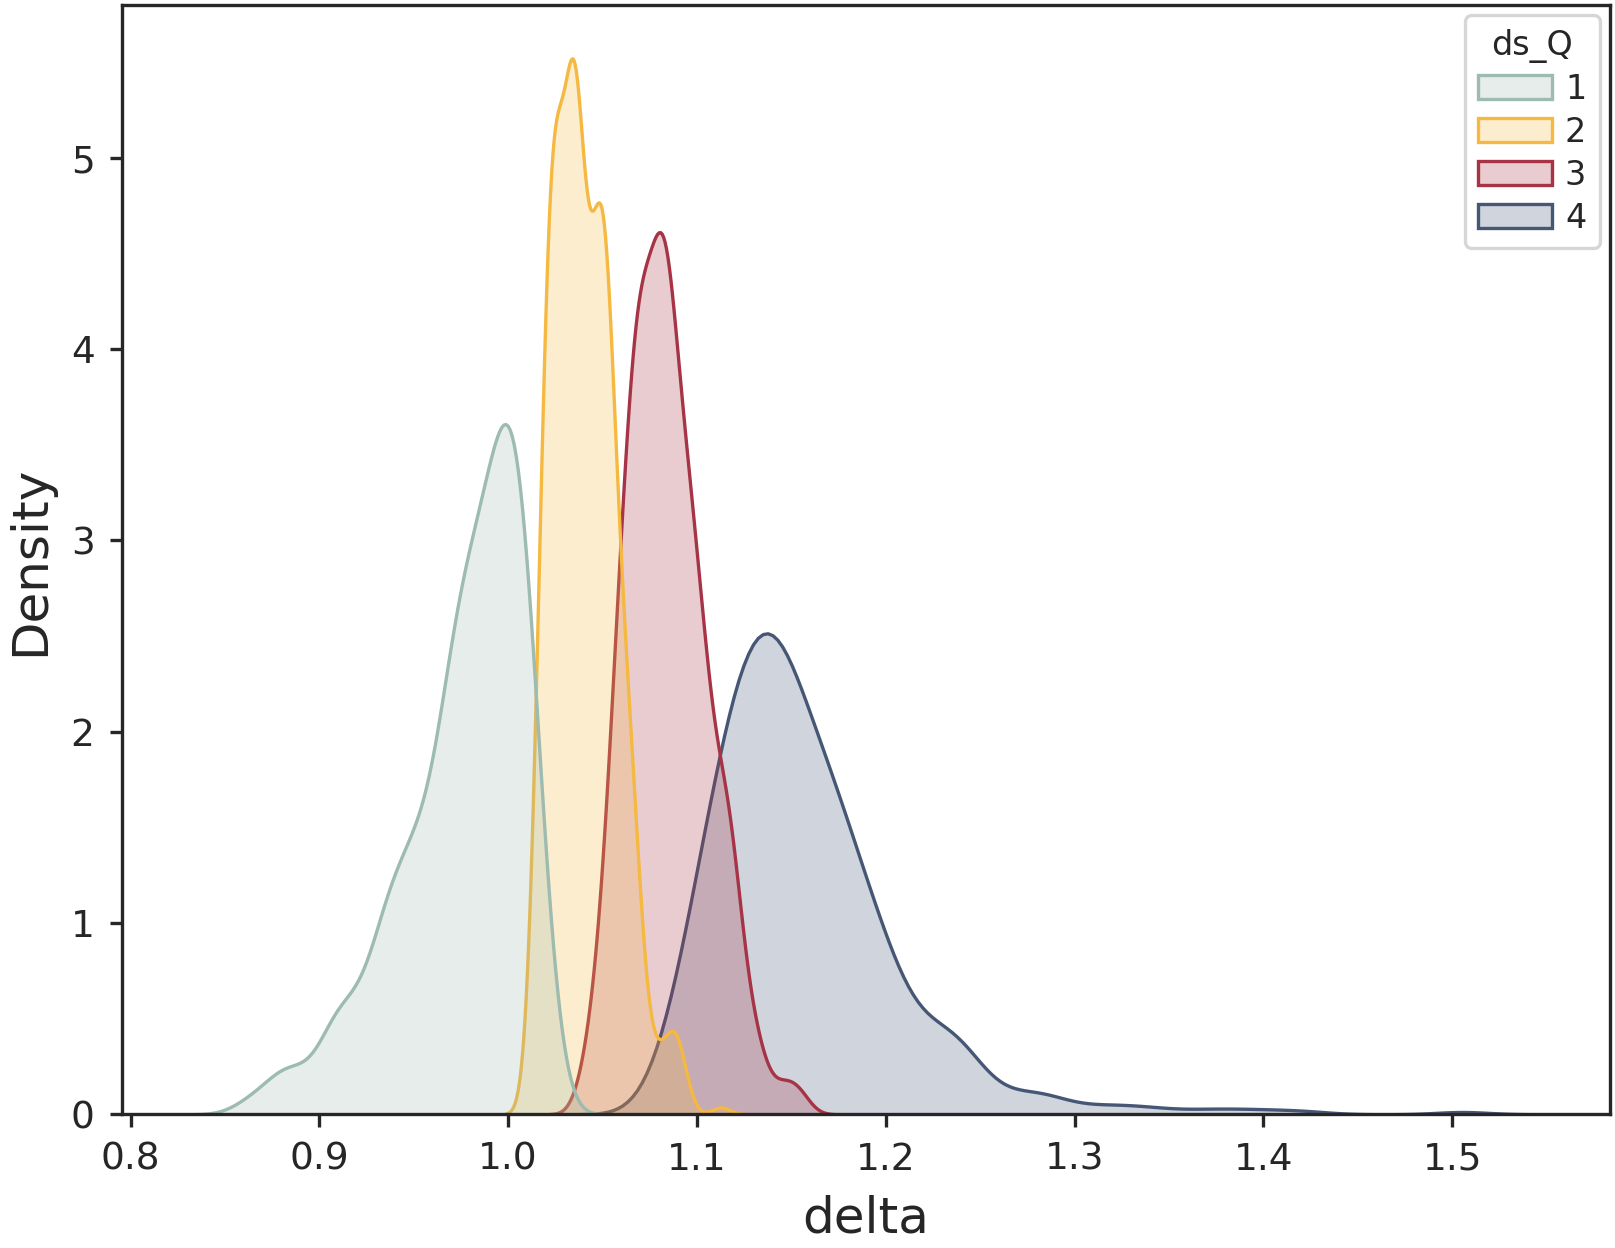

In [23]:
t0 = t0_tads_str.rename(columns={'domain_score': 't0_ds'})
t12 = t12_tads_str.rename(columns={'domain_score': 't12_ds'})

tads_df = t0.merge(t12[['chrom','start','end','t12_ds']], on=['chrom','start','end'], how='inner')
# tads_df['ds_Q'] = pd.qcut(tads_df['t12_ds'], q=4, labels=False) + 1

tads_df['ds_Q'] = pd.qcut(tads_df['t12_ds'] - tads_df['t0_ds'], q=4, labels=False) + 1

tads_df['delta'] = tads_df['t12_ds'] / tads_df['t0_ds']
sns.kdeplot(
    data=tads_df,
    x='delta',
    hue='ds_Q',
    fill=True,
    palette=list(reversed(COLORS)),
)


### rnaseq at tads

In [24]:
nbins = rescale_size

In [25]:
bin_table = clr_t0.bins()[:]

In [26]:
from coolpuppy import coolpup
pups_dict ={}
for q in sorted(tads_df['ds_Q'].unique()):
    current_df = tads_df[tads_df['ds_Q'] == q].copy()
    cc = coolpup.CoordCreator(current_df, resolution=10000, features_format='bed', local=True, rescale_flank=rescale_flank)
    pup_t0 = coolpup.PileUpper(clr_t0, cc, expected=t0_expected, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc = NPROC).pileupsWithControl()
    pup_t12 = coolpup.PileUpper(clr_t12, cc, expected=t12_expected, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc = NPROC).pileupsWithControl()
    pups_dict[int(q)] = (pup_t0, pup_t12)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4', 'chr4'): 35
INFO:coolpuppy:('chr2', 'chr2'): 42
INFO:coolpuppy:('chr1', 'chr1'): 47
INFO:coolpuppy:('chr3', 'chr3'): 44
INFO:coolpuppy:('chr6', 'chr6'): 34
INFO:coolpuppy:('chr5', 'chr5'): 29
INFO:coolpuppy:('chr8', 'chr8'): 29
INFO:coolpuppy:('chr7', 'chr7'): 31
INFO:coolpuppy:('chr9', 'chr9'): 20
INFO:coolpuppy:('chr11', 'chr11'): 32
INFO:coolpuppy:('chr13', 'chr13'): 16
INFO:coolpuppy:('chr14', 'chr14'): 21
INFO:coolpuppy:('chr15', 'chr15'): 22
INFO:coolpuppy:('chr10', 'chr10'): 29
INFO:coolpuppy:('chr16', 'chr16'): 17
INFO:coolpuppy:('chr12', 'chr12'): 31
INFO:coolpuppy:('chr17', 'chr17'): 26
INFO:coolpuppy:('chr18', 'chr18'): 16
INFO:coolpuppy:('chr19', 'chr19'): 17
INFO:coolpuppy:('chr21', 'chr21'): 12
INFO:coolpuppy:('chr20', 'chr20'): 11
INFO:coolpuppy:('chr22', 'chr22'): 11
INFO:coolpuppy:('chrX', 'chrX'): 25
INFO:coolpuppy:Total number of piled up windows: 597
INFO:coolpuppy:Rescaling with

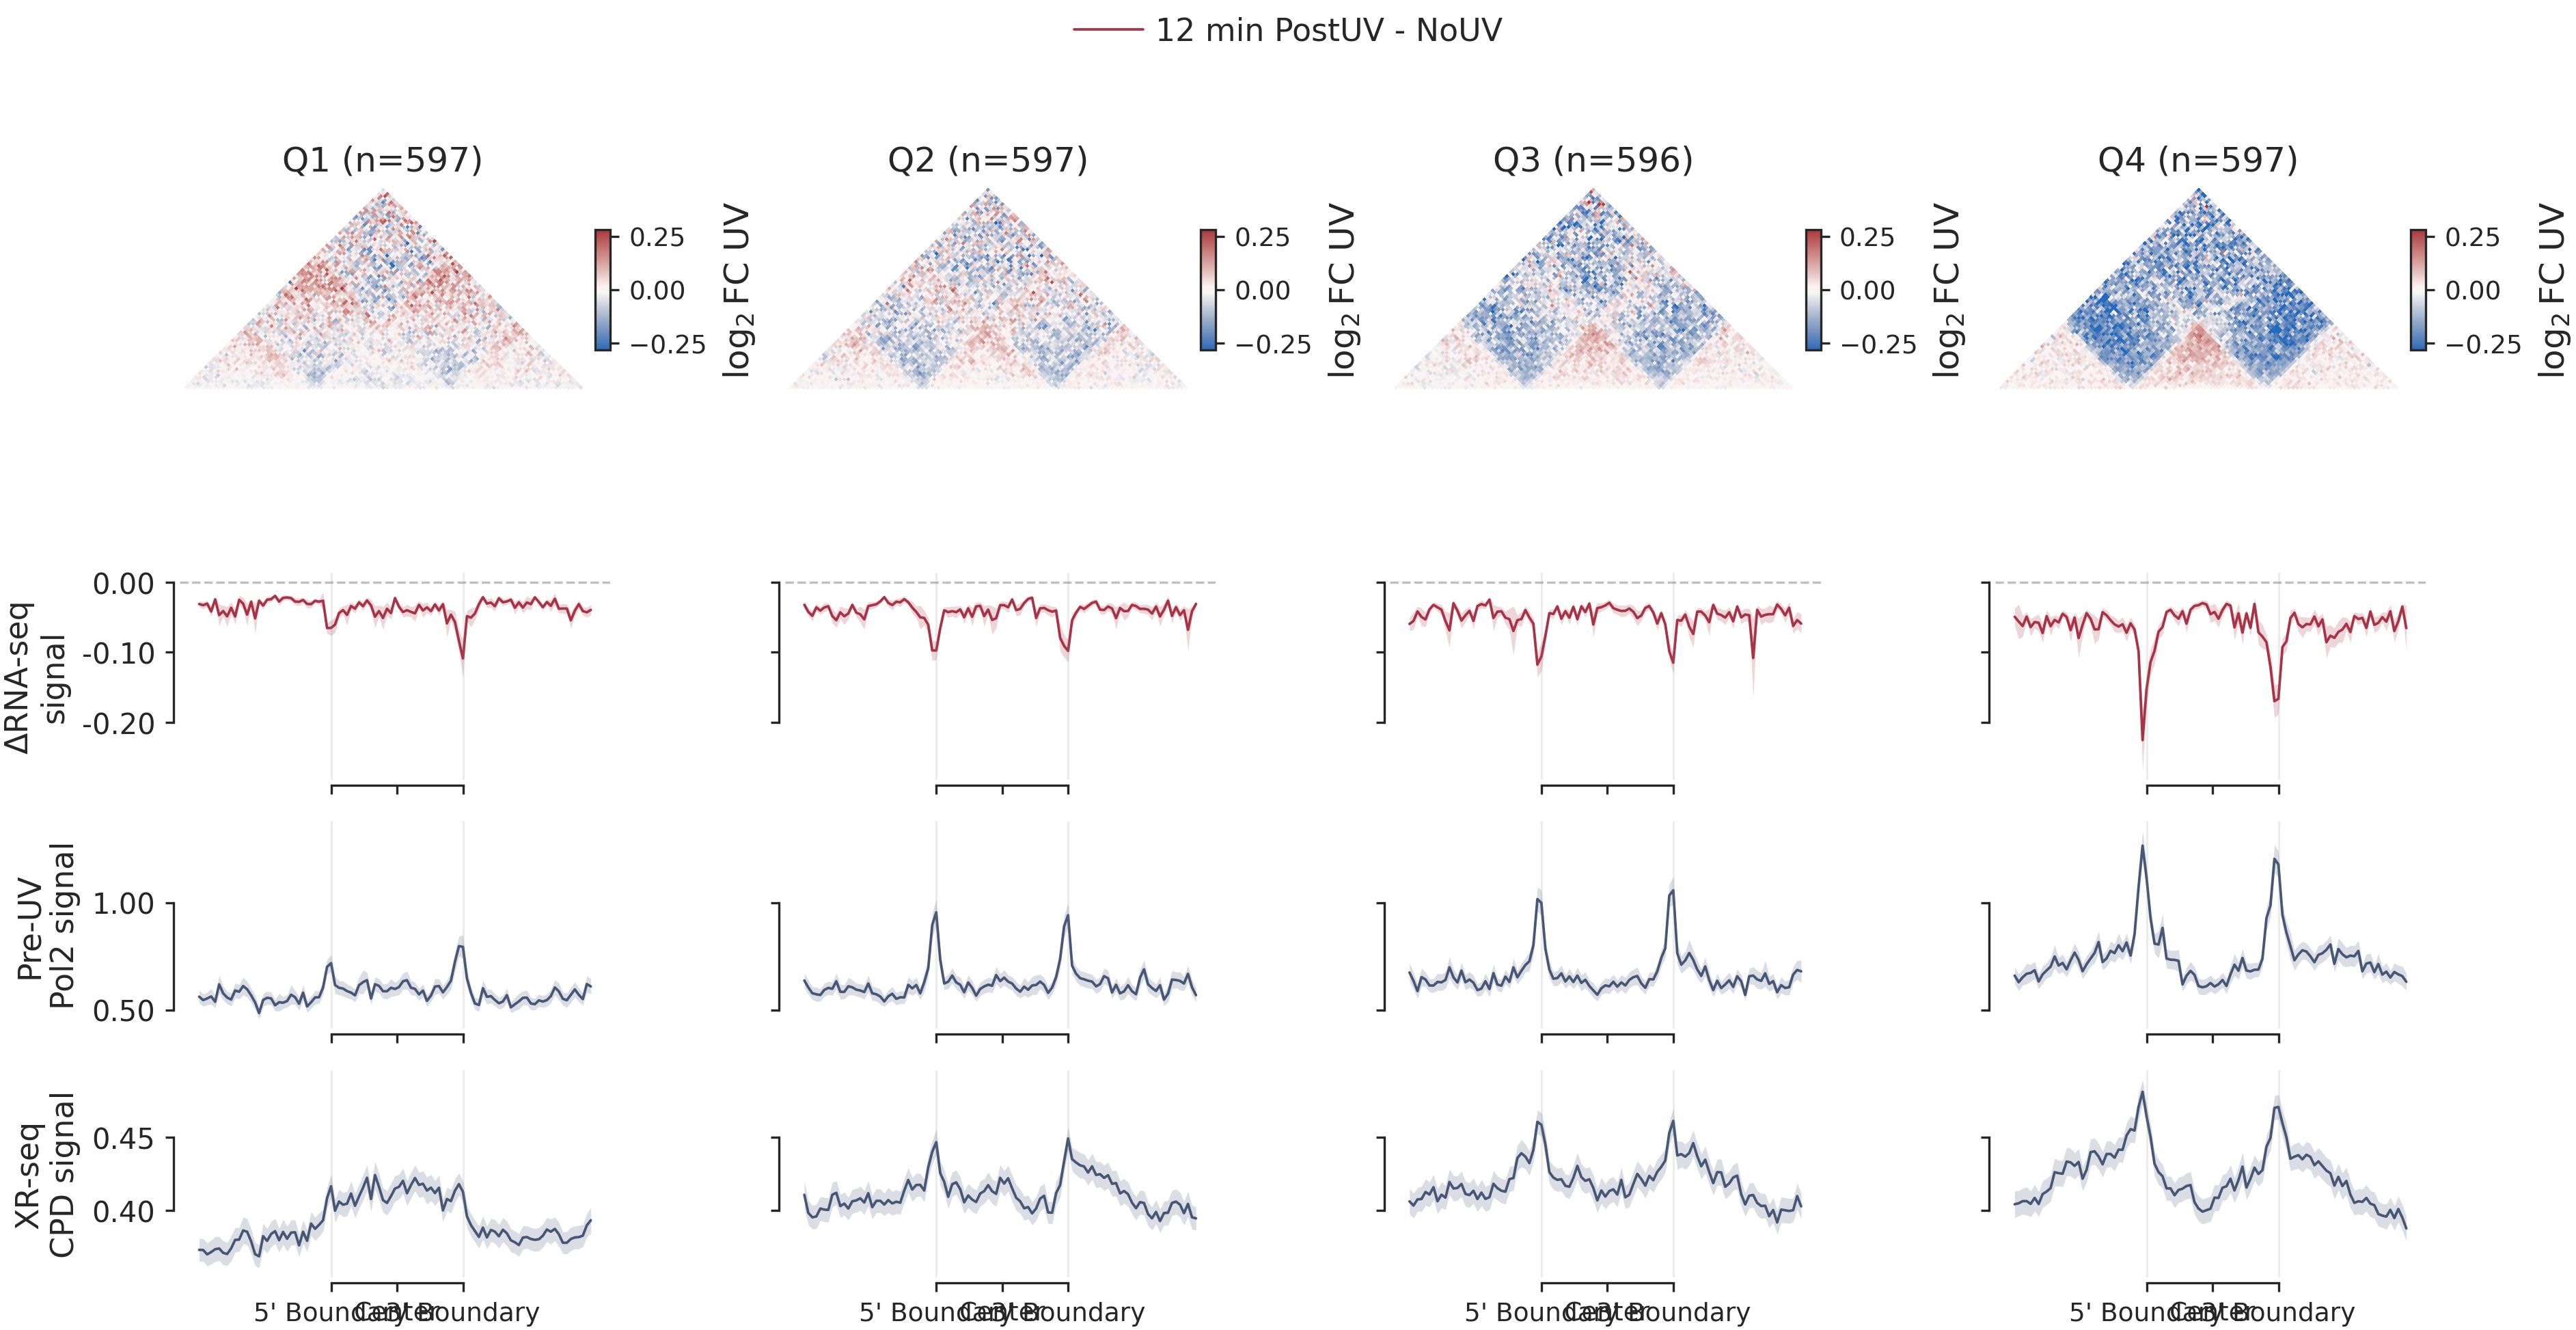

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from ggner_3d.plotting import hic_upper_triangle
from ggner_3d.plotting import COLORS
from ggner_3d import plotting

# =========================================================
# CONFIG
# =========================================================
SHADE_ALPHA = 0.20
LINEWIDTH = 0.9
EPS = 1e-6

RNA_LINES_TO_PLOT = ["t12"]

RNA_LINE_CONFIG = {
    "t12": {
        "time_key": "t12",
        "color": COLORS[1],
        "label": "12 min PostUV - NoUV",
    },
}

rna_bw_dict = {
    "t0": [
        "/home/carlos/Clone/ggner-3d/misc/rna_bw_v2/RNA_0.merged.cpm.bigWig"
    ],
    "t12": [
        "/home/carlos/Clone/ggner-3d/misc/rna_bw_v2/RNA_12.merged.cpm.bigWig"
    ],
}

pol2_dict = {
    "hela_nouv_pol2": [
        "/home/carlos/Clone/ggner-3d/misc/ENCFF144IVU.bigWig"
    ],
}

rep_dict = {
    "rep": [
        "/home/carlos/Clone/xr-ds-seq-snakemake/results/processed_files/"
        "hela12min_cpd_hg38_XR_dedup_1kb_CPM_canonical.bw"
    ],
}

# =========================================================
# HELPERS
# =========================================================
def nansem(x, axis=0):
    """
    Standard error of the mean ignoring NaNs.
    x shape: n_samples x n_bins
    """
    x = np.asarray(x)
    n = np.sum(~np.isnan(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    sem = sd / np.sqrt(n)
    sem = np.where(n > 1, sem, np.nan)
    return sem


def mean_sem_curve(x, axis=0):
    """
    Returns mean, mean - SEM, mean + SEM.
    """
    x = np.asarray(x)
    center = np.nanmean(x, axis=axis)
    sem = nansem(x, axis=axis)
    lower = center - sem
    upper = center + sem
    return center, lower, upper


def plot_mean_sem(
    ax,
    y_stack,
    color,
    label,
    linewidth=0.9,
    alpha=0.20,
):
    """
    y_stack shape: n_samples x n_bins
    """
    center, lower, upper = mean_sem_curve(y_stack, axis=0)
    x = np.arange(y_stack.shape[1])

    ax.plot(
        x,
        center,
        color=color,
        linewidth=linewidth,
        label=label,
    )
    ax.fill_between(
        x,
        lower,
        upper,
        color=color,
        alpha=alpha,
        linewidth=0,
    )


def validate_rna_lines(rna_lines_to_plot, rna_line_config):
    invalid = [x for x in rna_lines_to_plot if x not in rna_line_config]
    if invalid:
        raise ValueError(
            f"Invalid RNA_LINES_TO_PLOT entries: {invalid}. "
            f"Valid options are: {list(rna_line_config.keys())}"
        )


# =========================================================
# PREPARE TAD WINDOWS
# =========================================================
validate_rna_lines(RNA_LINES_TO_PLOT, RNA_LINE_CONFIG)

tads_df = tads_df.copy()
tads_df["length"] = tads_df["end"] - tads_df["start"]

tads_df["flank_start"] = (
    tads_df["start"] - (tads_df["length"] * rescale_flank).astype(int)
)
tads_df["flank_end"] = (
    tads_df["end"] + (tads_df["length"] * rescale_flank).astype(int)
)

quartiles = sorted(tads_df["ds_Q"].dropna().unique())

# =========================================================
# STACK SIGNALS BY QUARTILE
# =========================================================
tad_stacks_rna = {}
tad_stack_pol2 = {}
tad_stack_rep = {}

for q in quartiles:
    q_int = int(q)
    q_df = tads_df.loc[tads_df["ds_Q"] == q].copy()

    tad_stacks_rna[q_int] = stackup_bw_dict(
        bw_dict=rna_bw_dict,
        df=q_df,
        nbins=nbins,
    )

    tad_stack_pol2[q_int] = stackup_bw_dict(
        bw_dict=pol2_dict,
        df=q_df,
        nbins=nbins,
    )

    tad_stack_rep[q_int] = stackup_bw_dict(
        bw_dict=rep_dict,
        df=q_df,
        nbins=nbins,
    )

# =========================================================
# FIGURE SETUP
# =========================================================
plotting.update_rcparams()

fig, ax = plt.subplots(
    4,
    len(quartiles),
    figsize=(3.2 * len(quartiles), 6.5),
    sharey="row",
    gridspec_kw={"height_ratios": [1.4, 0.6, 0.6, 0.6]},
)

if len(quartiles) == 1:
    ax = ax[:, None]

unit_size = rescale_size // (2 * rescale_flank + 1)
fiveprime_bin = unit_size * rescale_flank
threeprime_bin = unit_size * (rescale_flank + 1)
tad_center_bin = (fiveprime_bin + threeprime_bin) / 2

custom_xticks = [fiveprime_bin, tad_center_bin, threeprime_bin]
custom_xticklabels = ["5' Boundary", "Center", "3' Boundary"]

# =========================================================
# ROW 1: Hi-C delta heatmaps
# =========================================================
mats = []

for q in quartiles:
    q_int = int(q)
    pup_t0, pup_t12 = pups_dict[q_int]

    divide_pup = np.log2(pup_t12["data"][0] + EPS) - np.log2(pup_t0["data"][0] + EPS)
    mats.append(divide_pup)

stacked_mats = np.stack(mats)

# symmetric scale around zero
abs_vmax = np.nanpercentile(np.abs(stacked_mats), 99)
vmin, vmax = -abs_vmax, abs_vmax

for i, q in enumerate(quartiles):
    q_int = int(q)
    pup_t0, pup_t12 = pups_dict[q_int]

    divide_pup = np.log2(pup_t12["data"][0] + EPS) - np.log2(pup_t0["data"][0] + EPS)

    h_ax = hic_upper_triangle(
        divide_pup,
        ax=ax[0, i],
        cmap="vlag",
        center=0,
        vmin=vmin,
        vmax=vmax,
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8),
    )

    cbar = h_ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$FC UV", labelpad=5)

    for artist in ax[0, i].images + ax[0, i].collections:
        artist.set_rasterized(True)

    n_q = len(tads_df.loc[tads_df["ds_Q"] == q])
    ax[0, i].set_title(f"Q{q_int} (n={n_q})", fontsize=12)

    ax[0, i].set_xticks([])
    ax[0, i].set_yticks([])

# =========================================================
# ROW 2: RNA delta, t12 only
# =========================================================
for k, v in tad_stacks_rna.items():
    a = ax[1, k - 1]

    for line_key in RNA_LINES_TO_PLOT:
        cfg = RNA_LINE_CONFIG[line_key]

        delta = v[cfg["time_key"]] - v["t0"]

        plot_mean_sem(
            a,
            delta,
            color=cfg["color"],
            label=cfg["label"],
            linewidth=LINEWIDTH,
            alpha=SHADE_ALPHA,
        )

    a.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

# =========================================================
# ROW 3: Pol2
# =========================================================
for k, v in tad_stack_pol2.items():
    a = ax[2, k - 1]

    plot_mean_sem(
        a,
        v["hela_nouv_pol2"],
        color=COLORS[0],
        label="Pre-UV Pol2",
        linewidth=LINEWIDTH,
        alpha=SHADE_ALPHA,
    )

# =========================================================
# ROW 4: Repair signal
# =========================================================
for k, v in tad_stack_rep.items():
    a = ax[3, k - 1]

    plot_mean_sem(
        a,
        v["rep"],
        color=COLORS[0],
        label="XR-seq CPD",
        linewidth=LINEWIDTH,
        alpha=SHADE_ALPHA,
    )

# =========================================================
# STYLING
# =========================================================
for row_i in [1, 2, 3]:
    for a in ax[row_i, :]:
        a.axvline(fiveprime_bin, color="grey", alpha=0.15, linewidth=0.8)
        a.axvline(threeprime_bin, color="grey", alpha=0.15, linewidth=0.8)

        a.set_xticks(custom_xticks)

        if row_i < 3:
            a.set_xticklabels([])
        else:
            a.set_xticklabels(custom_xticklabels)

        a.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f"{x:.2f}")
        )

        plotting.despine(ax=a)

ax[1, 0].set_ylabel("ΔRNA-seq\nsignal")
ax[2, 0].set_ylabel("Pre-UV\nPol2 signal")
ax[3, 0].set_ylabel("XR-seq\nCPD signal")

# Shared legend from RNA row only
handles, labels = ax[1, 0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=max(1, len(labels)),
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
        fontsize=11,
    )

for a in ax.flatten():
    plotting.despine(ax=a)
    a.tick_params(axis="both", which="major", labelsize=10)
    a.set_ylabel(a.get_ylabel(), fontsize=11)
    a.set_xlabel(a.get_xlabel(), fontsize=11)

# Apply bottom-row x tick labels last
for a in ax[3, :]:
    plt.setp(
        a.get_xticklabels(),
        rotation=0,
        ha="center",
        fontsize=9,
    )

fig.tight_layout()

fig.savefig(
    "/home/carlos/Clone/ggner-3d/figs/hela/"
    "hela_tads_stratified_by_isolation_change_preUV_vs_12mins_PostUV_difference.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "/home/carlos/Clone/ggner-3d/figs/hela/"
    "hela_tads_stratified_by_isolation_change_preUV_vs_12mins_PostUV_difference.svg",
    dpi=300,
    bbox_inches="tight",
)

plt.show()